# NetworkX

## Introduction: The World as Networks

From social circles and the internet to your brain's neurons and the global economy, our world is built on **networks**—collections of nodes connected by edges. NetworkX is Python's premier library for creating, analyzing, and visualizing these complex networks. This tutorial will guide you from complete beginner to confident network explorer, with practical code examples you can run in Jupyter.

---

## 1. Getting Started: Installation and Your First Graph

### Installation

In [ ]:
# In your terminal or notebook
!pip install networkx matplotlib

### Import and Create

In [2]:
# CELL 1: Import libraries and create your first graph
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

print("📦 Imported networkx version:", nx.__version__)

📦 Imported networkx version: 2.8.7


### What Type of Graph Do You Need?
NetworkX supports several graph types:
- **Graph (nx.Graph)**: Undirected edges (A-B is same as B-A)
- **DiGraph (nx.DiGraph)**: Directed edges (A→B ≠ B→A)
- **MultiGraph/MultiDiGraph**: Multiple parallel edges allowed

Let's create one of each:

In [3]:
# CELL 2: Creating different types of graphs
print("🔧 Creating different graph types...")

# 1. Simple undirected graph (like a social network)
G_undirected = nx.Graph()
G_undirected.add_edge("Alice", "Bob")
G_undirected.add_edge("Bob", "Charlie")

# 2. Directed graph (like a food web or webpage links)
G_directed = nx.DiGraph()
G_directed.add_edge("Producer", "Herbivore")
G_directed.add_edge("Herbivore", "Carnivore")

# 3. Weighted graph (edges have values)
G_weighted = nx.Graph()
G_weighted.add_edge("NYC", "Boston", weight=215)  # miles
G_weighted.add_edge("NYC", "DC", weight=225)

print(f"✅ Created: {type(G_undirected)} (undirected), {type(G_directed)} (directed), {type(G_weighted)} (weighted)")

🔧 Creating different graph types...
✅ Created: <class 'networkx.classes.graph.Graph'> (undirected), <class 'networkx.classes.digraph.DiGraph'> (directed), <class 'networkx.classes.graph.Graph'> (weighted)


---

## 2. Building Networks: From Empty to Complex

### 2.1 Adding Nodes and Edges
There are many ways to populate a graph. Let's explore them:

In [4]:
# CELL 3: Multiple ways to add nodes and edges
print("🧱 Building a social network step by step...")

# Method 1: One at a time
G = nx.Graph()
G.add_node("Alice")
G.add_node("Bob")
G.add_edge("Alice", "Bob")
print(f"Method 1: Nodes: {list(G.nodes())}, Edges: {list(G.edges())}")

# Method 2: Add multiple nodes/edges at once
G = nx.Graph()
G.add_nodes_from(["Alice", "Bob", "Charlie", "Diana"])
G.add_edges_from([("Alice", "Bob"), ("Bob", "Charlie"), ("Charlie", "Diana")])
print(f"Method 2: Nodes: {list(G.nodes())}, Edges: {list(G.edges())}")

# Method 3: Create from edge list directly
edge_list = [("Alice", "Bob"), ("Bob", "Charlie"), ("Charlie", "Diana")]
G = nx.Graph(edge_list)
print(f"Method 3: Nodes: {list(G.nodes())}, Edges: {list(G.edges())}")

# Method 4: Add nodes with attributes
G = nx.Graph()
G.add_node("Alice", age=25, occupation="Engineer")
G.add_node("Bob", age=30, occupation="Doctor")
G.add_edge("Alice", "Bob", relation="friends", since=2018)
print(f"\nMethod 4: Node attributes:")
for node in G.nodes(data=True):  # data=True includes attributes
    print(f"  {node}")
print("Edge attributes:")
for edge in G.edges(data=True):
    print(f"  {edge}")

🧱 Building a social network step by step...
Method 1: Nodes: ['Alice', 'Bob'], Edges: [('Alice', 'Bob')]
Method 2: Nodes: ['Alice', 'Bob', 'Charlie', 'Diana'], Edges: [('Alice', 'Bob'), ('Bob', 'Charlie'), ('Charlie', 'Diana')]
Method 3: Nodes: ['Alice', 'Bob', 'Charlie', 'Diana'], Edges: [('Alice', 'Bob'), ('Bob', 'Charlie'), ('Charlie', 'Diana')]

Method 4: Node attributes:
  ('Alice', {'age': 25, 'occupation': 'Engineer'})
  ('Bob', {'age': 30, 'occupation': 'Doctor'})
Edge attributes:
  ('Alice', 'Bob', {'relation': 'friends', 'since': 2018})


### 2.2 Creating Realistic Networks
Real-world networks aren't just random. Let's create some with known properties:

In [5]:
# CELL 4: Generating different types of network structures
print("🌐 Generating different network models...")

# 1. Random graph (Erdős–Rényi model)
# Each pair of nodes has probability p of being connected
G_random = nx.erdos_renyi_graph(n=20, p=0.1, seed=42)
print(f"1. Random graph: {G_random.number_of_nodes()} nodes, {G_random.number_of_edges()} edges")

# 2. Small-world (Watts-Strogatz model)
# High clustering + short paths (like social networks)
G_smallworld = nx.watts_strogatz_graph(n=20, k=4, p=0.3, seed=42)
print(f"2. Small-world: {G_smallworld.number_of_nodes()} nodes, {G_smallworld.number_of_edges()} edges")

# 3. Scale-free (Barabási-Albert model)
# Few hubs with many connections (like the internet)
G_scalefree = nx.barabasi_albert_graph(n=20, m=2, seed=42)
print(f"3. Scale-free: {G_scalefree.number_of_nodes()} nodes, {G_scalefree.number_of_edges()} edges")

# 4. Complete graph (everyone connected to everyone)
G_complete = nx.complete_graph(10)
print(f"4. Complete graph: {G_complete.number_of_nodes()} nodes, {G_complete.number_of_edges()} edges")
print(f"   (Should have n*(n-1)/2 = {10*9//2} edges for n=10)")

🌐 Generating different network models...
1. Random graph: 20 nodes, 23 edges
2. Small-world: 20 nodes, 40 edges
3. Scale-free: 20 nodes, 36 edges
4. Complete graph: 10 nodes, 45 edges
   (Should have n*(n-1)/2 = 45 edges for n=10)


### 2.3 Reading and Writing Graphs
NetworkX can read/write many formats:

In [6]:
# CELL 5: Reading and writing graph data
print("💾 Reading and writing graph data...")

# Create a sample graph
G = nx.erdos_renyi_graph(10, 0.3, seed=42)

# Write to different formats
nx.write_edgelist(G, "sample_graph.edgelist")
nx.write_adjlist(G, "sample_graph.adjlist")
nx.write_graphml(G, "sample_graph.graphml")

# Read them back
G_from_edgelist = nx.read_edgelist("sample_graph.edgelist")
G_from_adjlist = nx.read_adjlist("sample_graph.adjlist")
# Note: For GraphML, you might need to handle node types

print(f"Written and read graphs with {G_from_edgelist.number_of_nodes()} nodes")

# Clean up (optional)
import os
for file in ["sample_graph.edgelist", "sample_graph.adjlist", "sample_graph.graphml"]:
    if os.path.exists(file):
        os.remove(file)

💾 Reading and writing graph data...
Written and read graphs with 10 nodes


---

## 3. Network Inspection: What's in Your Graph?

### 3.1 Basic Properties

In [7]:
# CELL 6: Basic graph properties
print("🔍 Basic graph properties...")

# Create a more interesting graph
G = nx.karate_club_graph()  # Zachary's karate club, a classic dataset
print(f"1. Number of nodes: {G.number_of_nodes()}")
print(f"2. Number of edges: {G.number_of_edges()}")
print(f"3. Is directed? {G.is_directed()}")
print(f"4. Is weighted? {nx.is_weighted(G)}")
print(f"5. Is connected? {nx.is_connected(G)}")
print(f"6. Number of connected components: {nx.number_connected_components(G)}")
print(f"7. Density: {nx.density(G):.3f}")  # ratio of actual edges to possible edges
print(f"8. Diameter: {nx.diameter(G)}")  # longest shortest path
print(f"9. Average shortest path length: {nx.average_shortest_path_length(G):.2f}")

🔍 Basic graph properties...
1. Number of nodes: 34
2. Number of edges: 78
3. Is directed? False
4. Is weighted? True
5. Is connected? True
6. Number of connected components: 1
7. Density: 0.139
8. Diameter: 5
9. Average shortest path length: 2.41


### 3.2 Node and Edge Properties

In [8]:
# CELL 7: Examining specific nodes and edges
print("🎯 Examining specific nodes and edges...")

# Let's work with a smaller, more manageable graph
G = nx.Graph()
G.add_edges_from([
    ("Alice", "Bob"),
    ("Alice", "Charlie"),
    ("Bob", "Charlie"),
    ("Charlie", "Diana"),
    ("Diana", "Eve")
])

print(f"Nodes: {list(G.nodes())}")
print(f"Edges: {list(G.edges())}")
print()

# What's connected to Alice?
print("1. Alice's connections (neighbors):")
for neighbor in G.neighbors("Alice"):
    print(f"   - {neighbor}")

# What edges involve Charlie?
print("\n2. Edges connected to Charlie:")
for edge in G.edges("Charlie"):
    print(f"   - {edge}")

# Degree (number of connections) of each node
print("\n3. Degree (number of connections) of each node:")
for node in G.nodes():
    print(f"   {node}: degree = {G.degree(node)}")

# Get all degrees at once
degree_dict = dict(G.degree())
print(f"\n4. Degree dictionary: {degree_dict}")

🎯 Examining specific nodes and edges...
Nodes: ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve']
Edges: [('Alice', 'Bob'), ('Alice', 'Charlie'), ('Bob', 'Charlie'), ('Charlie', 'Diana'), ('Diana', 'Eve')]

1. Alice's connections (neighbors):
   - Bob
   - Charlie

2. Edges connected to Charlie:
   - ('Charlie', 'Alice')
   - ('Charlie', 'Bob')
   - ('Charlie', 'Diana')

3. Degree (number of connections) of each node:
   Alice: degree = 2
   Bob: degree = 2
   Charlie: degree = 3
   Diana: degree = 2
   Eve: degree = 1

4. Degree dictionary: {'Alice': 2, 'Bob': 2, 'Charlie': 3, 'Diana': 2, 'Eve': 1}


### 3.3 Working with Attributes

In [9]:
# CELL 8: Adding and accessing attributes
print("🏷️ Working with node and edge attributes...")

# Create a graph with rich attributes
G = nx.Graph()

# Add nodes with attributes
G.add_node("Alice", age=25, city="New York", profession="Engineer")
G.add_node("Bob", age=30, city="Boston", profession="Doctor")
G.add_node("Charlie", age=35, city="San Francisco", profession="Artist")

# Add edges with attributes
G.add_edge("Alice", "Bob", weight=0.8, relation="friends", since=2015)
G.add_edge("Bob", "Charlie", weight=0.5, relation="colleagues", since=2018)
G.add_edge("Alice", "Charlie", weight=0.3, relation="acquaintances", since=2020)

# Access node attributes
print("1. Node attributes:")
for node, attrs in G.nodes(data=True):
    print(f"   {node}: {attrs}")

# Access edge attributes
print("\n2. Edge attributes:")
for u, v, attrs in G.edges(data=True):
    print(f"   ({u}, {v}): {attrs}")

# Get specific attributes
print(f"\n3. Alice's age: {G.nodes['Alice']['age']}")
print(f"4. Weight of Alice-Bob edge: {G.edges[('Alice', 'Bob')]['weight']}")

# Update attributes
G.nodes["Alice"]["age"] = 26
G.edges[("Alice", "Bob")]["weight"] = 0.9
print(f"\n5. Updated Alice's age: {G.nodes['Alice']['age']}")
print(f"6. Updated Alice-Bob weight: {G.edges[('Alice', 'Bob')]['weight']}")

🏷️ Working with node and edge attributes...
1. Node attributes:
   Alice: {'age': 25, 'city': 'New York', 'profession': 'Engineer'}
   Bob: {'age': 30, 'city': 'Boston', 'profession': 'Doctor'}
   Charlie: {'age': 35, 'city': 'San Francisco', 'profession': 'Artist'}

2. Edge attributes:
   (Alice, Bob): {'weight': 0.8, 'relation': 'friends', 'since': 2015}
   (Alice, Charlie): {'weight': 0.3, 'relation': 'acquaintances', 'since': 2020}
   (Bob, Charlie): {'weight': 0.5, 'relation': 'colleagues', 'since': 2018}

3. Alice's age: 25
4. Weight of Alice-Bob edge: 0.8

5. Updated Alice's age: 26
6. Updated Alice-Bob weight: 0.9


---

## 4. Visualization: Making Networks Visible

### 4.1 Basic Visualization


BASIC GRAPH VISUALIZATION

GRAPH SUMMARY
Number of nodes : 15
Number of edges : 16
Density         : 0.152
Average degree  : 2.13


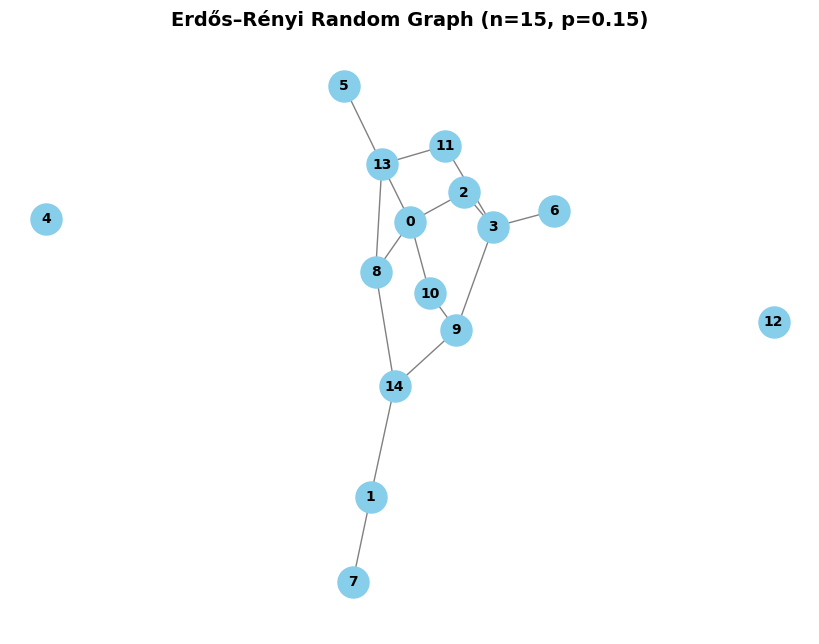

In [5]:
# CELL 9: Basic graph visualization

import networkx as nx
import matplotlib.pyplot as plt


def create_random_graph(num_nodes=15, edge_prob=0.15, seed=43):
    """Create an Erdős–Rényi random graph."""
    return nx.erdos_renyi_graph(num_nodes, edge_prob, seed=seed)


def compute_graph_stats(G):
    """Compute basic graph statistics."""
    return {
        "nodes": G.number_of_nodes(),
        "edges": G.number_of_edges(),
        "density": nx.density(G),
        "avg_degree": sum(dict(G.degree()).values()) / G.number_of_nodes(),
    }


def draw_graph(G, title="Graph Visualization", seed=43):
    """Draw a graph with consistent styling."""
    plt.figure(figsize=(8, 6))

    pos = nx.spring_layout(G, seed=seed)

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color="skyblue",
        node_size=500,
        edge_color="gray",
        font_size=10,
        font_weight="bold",
    )

    plt.title(title, fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.show()


def print_graph_summary(stats):
    """Print formatted graph statistics."""
    print("\n" + "=" * 50)
    print("GRAPH SUMMARY")
    print("=" * 50)
    print(f"Number of nodes : {stats['nodes']}")
    print(f"Number of edges : {stats['edges']}")
    print(f"Density         : {stats['density']:.3f}")
    print(f"Average degree  : {stats['avg_degree']:.2f}")


# =========================
# Main Execution
# =========================
print("\n" + "=" * 50)
print("BASIC GRAPH VISUALIZATION")
print("=" * 50)

G = create_random_graph(num_nodes=15, edge_prob=0.15, seed=42)

stats = compute_graph_stats(G)
print_graph_summary(stats)

draw_graph(G, title="Erdős–Rényi Random Graph (n=15, p=0.15)")

### 4.2 Customizing Visualizations

✨ Advanced visualization with customization...


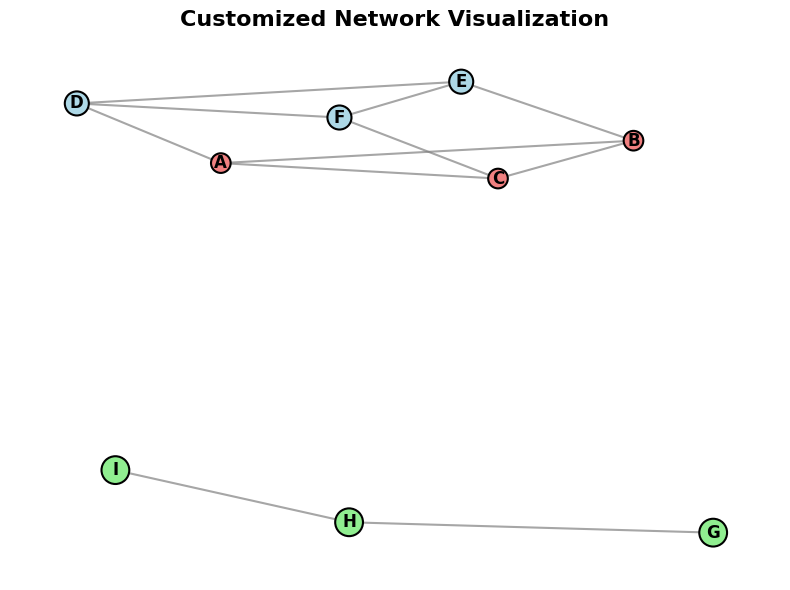

In [3]:
# CELL 10: Advanced visualization with customization
print("✨ Advanced visualization with customization...")

# Create a graph with different node types
G = nx.Graph()

# Add nodes with 'type' attribute
G.add_nodes_from(["A", "B", "C"], type="red", size=200)
G.add_nodes_from(["D", "E", "F"], type="blue", size=300)
G.add_nodes_from(["G", "H", "I"], type="green", size=400)

# Add edges
G.add_edges_from([
    ("A", "B"), ("A", "C"), ("B", "C"),  # Triangle
    ("D", "E"), ("E", "F"), ("F", "D"),  # Another triangle
    ("G", "H"), ("H", "I"),              # Line
    ("A", "D"), ("B", "E"), ("C", "F")   # Connections between groups
])

# Set up the plot
plt.figure(figsize=(8, 6))

# Create a layout
pos = nx.spring_layout(G, seed=42, k=0.5)  # k controls spacing

# Color nodes by type
node_colors = []
node_sizes = []
for node in G.nodes():
    if G.nodes[node].get('type') == 'red':
        node_colors.append('lightcoral')
        node_sizes.append(200)
    elif G.nodes[node].get('type') == 'blue':
        node_colors.append('lightblue')
        node_sizes.append(300)
    else:  # green
        node_colors.append('lightgreen')
        node_sizes.append(400)

# Draw nodes
nx.draw_networkx_nodes(G, pos, 
                       node_color=node_colors, 
                       node_size=node_sizes,
                       edgecolors='black',
                       linewidths=1.5)

# Draw edges with different styles
nx.draw_networkx_edges(G, pos, 
                       width=1.5, 
                       edge_color='gray',
                       style='-',  # solid line
                       alpha=0.7)

# Draw labels
nx.draw_networkx_labels(G, pos, 
                        font_size=12, 
                        font_weight='bold',
                        font_color='black')

plt.title("Customized Network Visualization", fontsize=16, fontweight='bold')
plt.axis('off')  # Turn off the axis
plt.tight_layout()
plt.show()

### 4.3 Visualizing Directed and Weighted Graphs


DIRECTED & WEIGHTED GRAPH VISUALIZATION


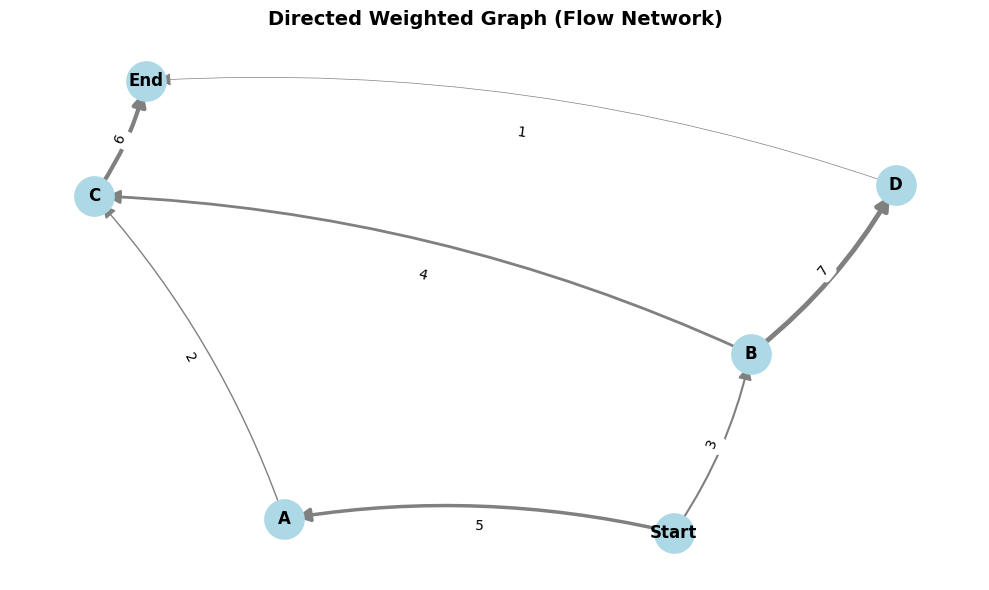


------------------------------------------------------------
ADJACENCY MATRIX (WEIGHTED)
------------------------------------------------------------
Node ordering used: ['A', 'B', 'C', 'D', 'End', 'Start']

              A      B      C      D    End  Start
      ------------------------------------------------
     A |      .      .      2      .      .      .
     B |      .      .      4      7      .      .
     C |      .      .      .      .      6      .
     D |      .      .      .      .      1      .
   End |      .      .      .      .      .      .
 Start |      5      3      .      .      .      .

------------------------------------------------------------
ADJACENCY MATRIX (NetworkX Reference)
------------------------------------------------------------
     A | [0, 0, 2, 0, 0, 0]
     B | [0, 0, 4, 7, 0, 0]
     C | [0, 0, 0, 0, 6, 0]
     D | [0, 0, 0, 0, 1, 0]
   End | [0, 0, 0, 0, 0, 0]
 Start | [5, 3, 0, 0, 0, 0]

-------------------------------------------------

In [26]:
# CELL 11: Directed and weighted graph visualization
print("\n" + "=" * 60)
print("DIRECTED & WEIGHTED GRAPH VISUALIZATION")
print("=" * 60)

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Create a directed, weighted graph
G = nx.DiGraph()

# Add edges with weights
edges_with_weights = [
    ("Start", "A", 5),
    ("Start", "B", 3),
    ("A", "C", 2),
    ("B", "C", 4),
    ("B", "D", 7),
    ("C", "End", 6),
    ("D", "End", 1),
]

for u, v, w in edges_with_weights:
    G.add_edge(u, v, weight=w)

plt.figure(figsize=(10, 6))

# Position nodes
pos = nx.spring_layout(G, seed=42)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color="lightblue", node_size=800)

# Draw edges with width proportional to weight
edge_widths = [G[u][v]["weight"] for u, v in G.edges()]
nx.draw_networkx_edges(
    G,
    pos,
    width=[w / 2 for w in edge_widths],
    edge_color="gray",
    arrowstyle="-|>",
    arrowsize=20,
    connectionstyle="arc3,rad=0.1",
)

# Draw edge labels (weights)
edge_labels = {(u, v): f"{G[u][v]['weight']}" for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

# Draw node labels
nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold")

plt.title("Directed Weighted Graph (Flow Network)", fontsize=14, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()

# =========================
# Adjacency Matrix Section
# =========================
print("\n" + "-" * 60)
print("ADJACENCY MATRIX (WEIGHTED)")
print("-" * 60)

# Sorted node list
nodes = sorted(G.nodes())
print(f"Node ordering used: {nodes}\n")

# Create adjacency matrix
n = len(nodes)
adj_matrix = np.zeros((n, n))

node_to_index = {node: i for i, node in enumerate(nodes)}

# Fill adjacency matrix
for u, v, data in G.edges(data=True):
    i = node_to_index[u]
    j = node_to_index[v]
    adj_matrix[i][j] = data.get("weight", 1)

# Pretty print matrix
print("         " + " ".join(f"{node:>6}" for node in nodes))
print("      " + "-" * (8 * n))

for i, node in enumerate(nodes):
    row_str = " ".join(f"{int(w):6d}" if w > 0 else f"{'.':>6}" for w in adj_matrix[i])
    print(f"{node:>6} | {row_str}")

# =========================
# NetworkX Matrix (Reference)
# =========================
print("\n" + "-" * 60)
print("ADJACENCY MATRIX (NetworkX Reference)")
print("-" * 60)

adj_matrix_nx = nx.to_numpy_array(G, nodelist=nodes, weight="weight")

for i, node in enumerate(nodes):
    row = [int(x) for x in adj_matrix_nx[i]]
    print(f"{node:>6} | {row}")

# =========================
# Graph Summary
# =========================
print("\n" + "-" * 60)
print("GRAPH SUMMARY")
print("-" * 60)

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
total_weight = sum(data["weight"] for _, _, data in G.edges(data=True))

print(f"Number of nodes : {num_nodes}")
print(f"Number of edges : {num_edges}")
print(f"Total weight    : {total_weight}")

# =========================
# Node Degree Information
# =========================
print("\n" + "-" * 60)
print("NODE DEGREE (WEIGHTED IN/OUT)")
print("-" * 60)

for node in nodes:
    in_deg = G.in_degree(node, weight="weight")
    out_deg = G.out_degree(node, weight="weight")
    print(f"{node:>6} | In-degree: {in_deg:>3} | Out-degree: {out_deg:>3}")

---

## 5. Network Analysis: Extracting Insights

### 5.1 Centrality Measures: Who's Important?
Centrality measures identify the most important nodes in a network:

⭐ Centrality measures: Who's important in the network?
1. Degree Centrality (most connections):
   Node 33: 0.515
   Node  0: 0.485
   Node 32: 0.364
   Node  2: 0.303
   Node  1: 0.273

2. Betweenness Centrality (key bridges):
   Node  0: 0.438
   Node 33: 0.304
   Node 32: 0.145
   Node  2: 0.144
   Node 31: 0.138

3. Closeness Centrality (close to everyone):
   Node  0: 0.569
   Node  2: 0.559
   Node 33: 0.550
   Node 31: 0.541
   Node  8: 0.516

4. Eigenvector Centrality (connected to important nodes):
   Node 33: 0.373
   Node  0: 0.355
   Node  2: 0.317
   Node 32: 0.309
   Node  1: 0.266


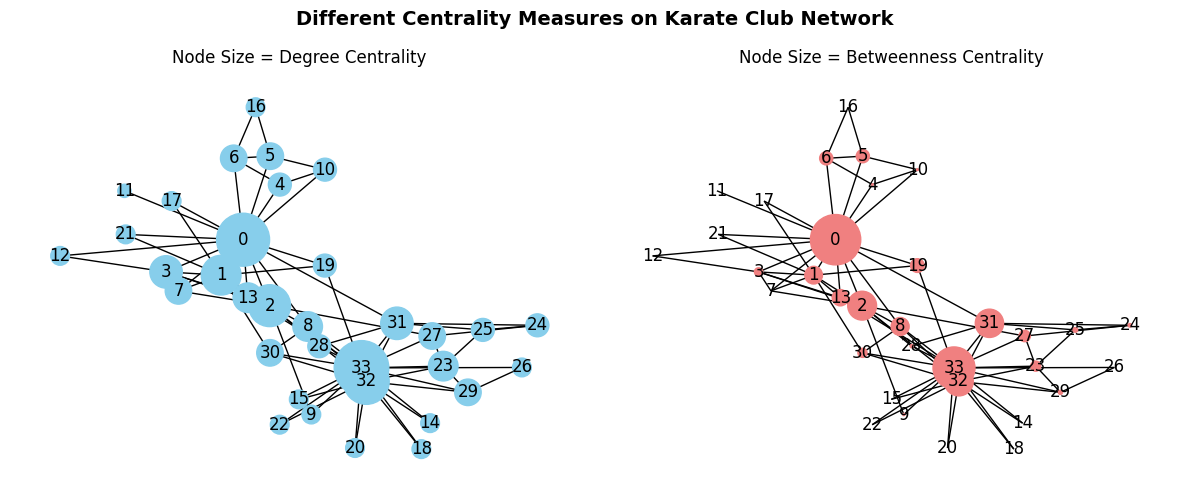

In [13]:
# CELL 12: Centrality measures
print("⭐ Centrality measures: Who's important in the network?")

# Use a classic dataset: Zachary's Karate Club
G = nx.karate_club_graph()

# 1. Degree centrality: Number of connections
degree_centrality = nx.degree_centrality(G)
print("1. Degree Centrality (most connections):")
for node, centrality in sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"   Node {node:2d}: {centrality:.3f}")

# 2. Betweenness centrality: Controls information flow
betweenness = nx.betweenness_centrality(G)
print("\n2. Betweenness Centrality (key bridges):")
for node, centrality in sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"   Node {node:2d}: {centrality:.3f}")

# 3. Closeness centrality: Quickly reaches everyone
closeness = nx.closeness_centrality(G)
print("\n3. Closeness Centrality (close to everyone):")
for node, centrality in sorted(closeness.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"   Node {node:2d}: {centrality:.3f}")

# 4. Eigenvector centrality: Connected to well-connected nodes
eigenvector = nx.eigenvector_centrality(G, max_iter=1000)
print("\n4. Eigenvector Centrality (connected to important nodes):")
for node, centrality in sorted(eigenvector.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"   Node {node:2d}: {centrality:.3f}")

# Visualize with node size proportional to degree centrality
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
pos = nx.spring_layout(G, seed=42)
node_sizes = [degree_centrality[node] * 3000 for node in G.nodes()]
nx.draw(G, pos, node_size=node_sizes, node_color='skyblue', with_labels=True)
plt.title("Node Size = Degree Centrality", fontsize=12)

plt.subplot(1, 2, 2)
node_sizes = [betweenness[node] * 3000 for node in G.nodes()]
nx.draw(G, pos, node_size=node_sizes, node_color='lightcoral', with_labels=True)
plt.title("Node Size = Betweenness Centrality", fontsize=12)

plt.suptitle("Different Centrality Measures on Karate Club Network", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Finding Communities

🤝 Finding communities in networks...
🤝 Finding communities in networks (using NetworkX built-in methods)...

1. Greedy Modularity Communities (Clauset-Newman-Moore):
   Community 0: [8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
   Community 1: [1, 2, 3, 7, 9, 12, 13, 17, 21]
   Community 2: [0, 4, 5, 6, 10, 11, 16, 19]

2. Label Propagation Communities:
   Community 0: [0, 1, 3, 4, 7, 10, 11, 12, 13, 17, 19, 21, 24, 25, 31]
   Community 1: [2, 8, 9, 14, 15, 18, 20, 22, 23, 26, 27, 28, 29, 30, 32, 33]
   Community 2: [5, 6, 16]


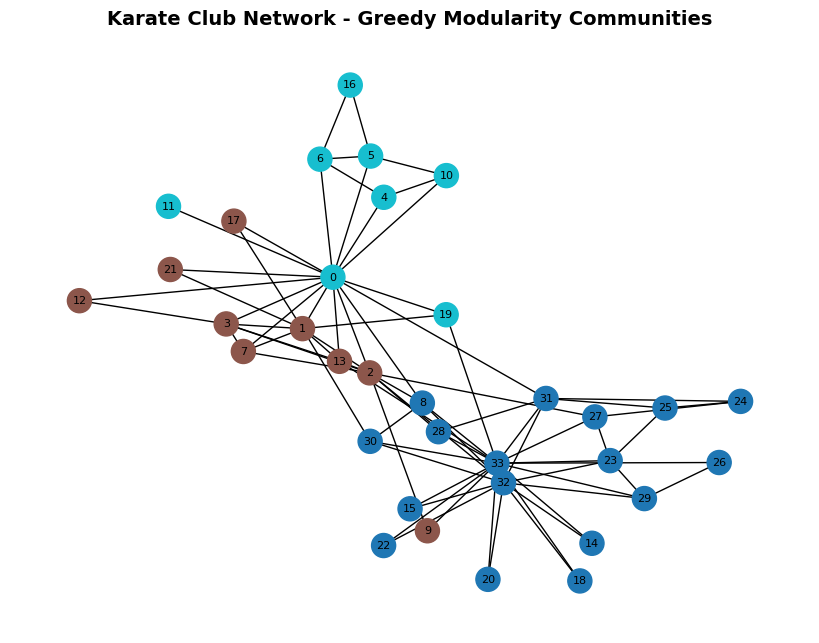


✅ Successfully detected 3 communities!


In [20]:
# CELL 13: Community detection
print("🤝 Finding communities in networks...")

# Alternative approach using networkx's built-in community detection
# (No external packages needed)

import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import (
    greedy_modularity_communities,
    label_propagation_communities,
)

print("🤝 Finding communities in networks (using NetworkX built-in methods)...")

# Use the karate club network
G = nx.karate_club_graph()

# Method 1: Greedy Modularity Communities (Clauset-Newman-Moore)
print("\n1. Greedy Modularity Communities (Clauset-Newman-Moore):")
communities_greedy = list(greedy_modularity_communities(G))
for i, comm in enumerate(communities_greedy):
    print(f"   Community {i}: {sorted(comm)}")

# Method 2: Label Propagation
print("\n2. Label Propagation Communities:")
communities_label = list(label_propagation_communities(G))
for i, comm in enumerate(communities_label):
    print(f"   Community {i}: {sorted(comm)}")

# Visualize with greedy modularity communities
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)

# Create color map for communities
node_colors = []
color_map = {node: i for i, comm in enumerate(communities_greedy) for node in comm}
node_colors = [color_map[node] for node in G.nodes()]

nx.draw(
    G,
    pos,
    node_color=node_colors,
    cmap=plt.cm.tab10,
    node_size=300,
    with_labels=True,
    font_size=8,
)

plt.title(
    "Karate Club Network - Greedy Modularity Communities",
    fontsize=14,
    fontweight="bold",
)
plt.show()

print(f"\n✅ Successfully detected {len(communities_greedy)} communities!")

### 5.3 Path Analysis

🛣️  Path analysis: Finding connections between nodes...
Graph has 12 cities and 12 connections

1. Shortest path from NYC to Miami:
   ['NYC', 'Philly', 'DC', 'Atlanta', 'Miami']
   Distance: 4 hops

2. All shortest paths from NYC to Miami:
   Path 1: ['NYC', 'Philly', 'DC', 'Atlanta', 'Miami']

3. Shortest path length NYC to Seattle: 3

4. Is the graph connected? True
   Diameter (longest shortest path): 6
   Average shortest path length: 3.12


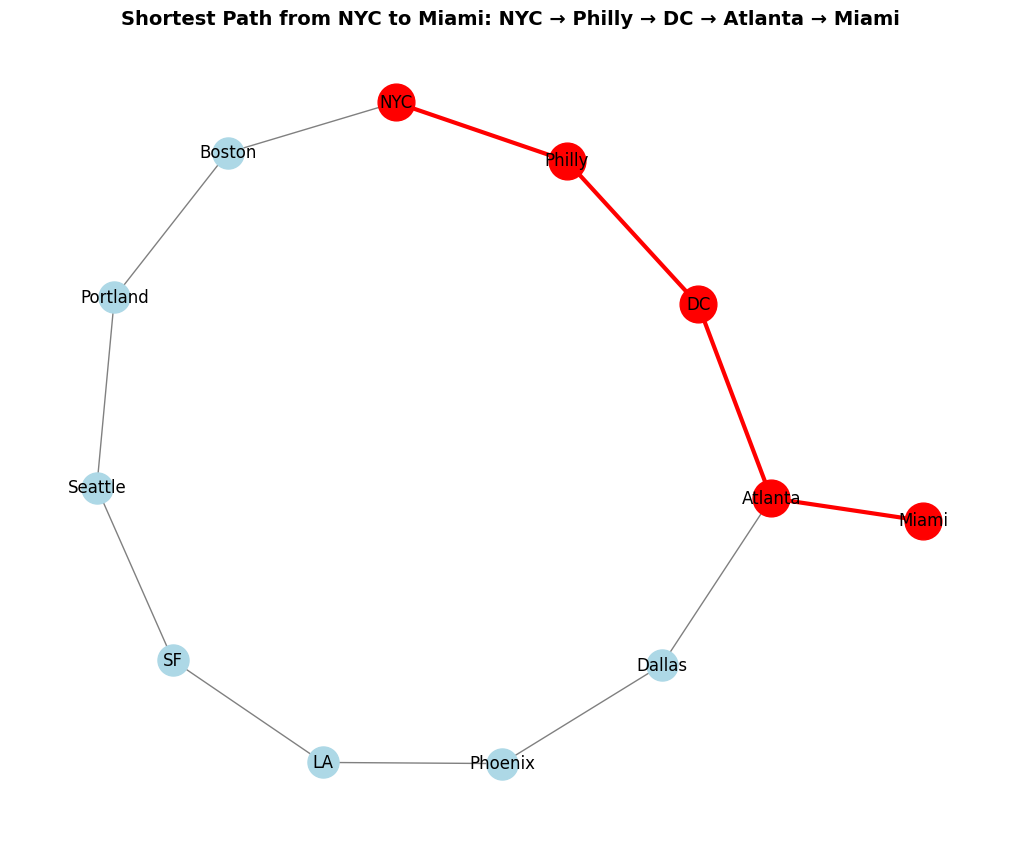

In [15]:
# CELL 14: Finding paths in networks
print("🛣️  Path analysis: Finding connections between nodes...")

# Create a more complex graph
G = nx.Graph()
G.add_edges_from([
    ("NYC", "Boston"),
    ("NYC", "Philly"),
    ("Boston", "Portland"),
    ("Philly", "DC"),
    ("DC", "Atlanta"),
    ("Atlanta", "Miami"),
    ("Portland", "Seattle"),
    ("Seattle", "SF"),
    ("SF", "LA"),
    ("LA", "Phoenix"),
    ("Phoenix", "Dallas"),
    ("Dallas", "Atlanta")
])

print(f"Graph has {G.number_of_nodes()} cities and {G.number_of_edges()} connections")

# 1. Shortest path
print("\n1. Shortest path from NYC to Miami:")
path = nx.shortest_path(G, source="NYC", target="Miami")
print(f"   {path}")
print(f"   Distance: {len(path)-1} hops")

# 2. All shortest paths
print("\n2. All shortest paths from NYC to Miami:")
all_paths = list(nx.all_shortest_paths(G, source="NYC", target="Miami"))
for i, path in enumerate(all_paths, 1):
    print(f"   Path {i}: {path}")

# 3. Shortest path length
print(f"\n3. Shortest path length NYC to Seattle: {nx.shortest_path_length(G, source='NYC', target='Seattle')}")

# 4. Check connectivity
print(f"\n4. Is the graph connected? {nx.is_connected(G)}")
if nx.is_connected(G):
    print(f"   Diameter (longest shortest path): {nx.diameter(G)}")
    print(f"   Average shortest path length: {nx.average_shortest_path_length(G):.2f}")

# 5. Visualize with the shortest path highlighted
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)

# Draw the whole graph
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=500, edge_color='gray')

# Highlight the shortest path
path_edges = list(zip(path[:-1], path[1:]))
nx.draw_networkx_nodes(G, pos, nodelist=path, node_color='red', node_size=700)
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

plt.title(f"Shortest Path from NYC to Miami: {' → '.join(path)}", fontsize=14, fontweight='bold')
plt.show()

---

## 6. Real-World Example: Analyzing a Social Network

Let's put it all together with a realistic example:

📧 Analyzing a corporate email network...
Network has 16 employees and 46 email connections

📊 Network Analysis:
1. Density: 0.192 (19.2% of possible connections exist)
2. Is strongly connected? False
3. Number of weakly connected components: 1

👥 Key Employees (by centrality):

Most active email senders:
  Frank (Sales): 6 recipients
  Alice (Engineering): 5 recipients
  Jack (Marketing): 5 recipients
  Bob (Engineering): 4 recipients
  Charlie (Engineering): 4 recipients

Most popular email recipients:
  Alice (Engineering): 6 senders
  Frank (Sales): 5 senders
  Eve (Engineering): 4 senders
  Grace (Sales): 4 senders
  Jack (Marketing): 4 senders

Key bridges between departments:
  Frank (Sales): 0.299
  Alice (Engineering): 0.275
  Karen (Marketing): 0.131
  Jack (Marketing): 0.122
  Ivy (Sales): 0.086


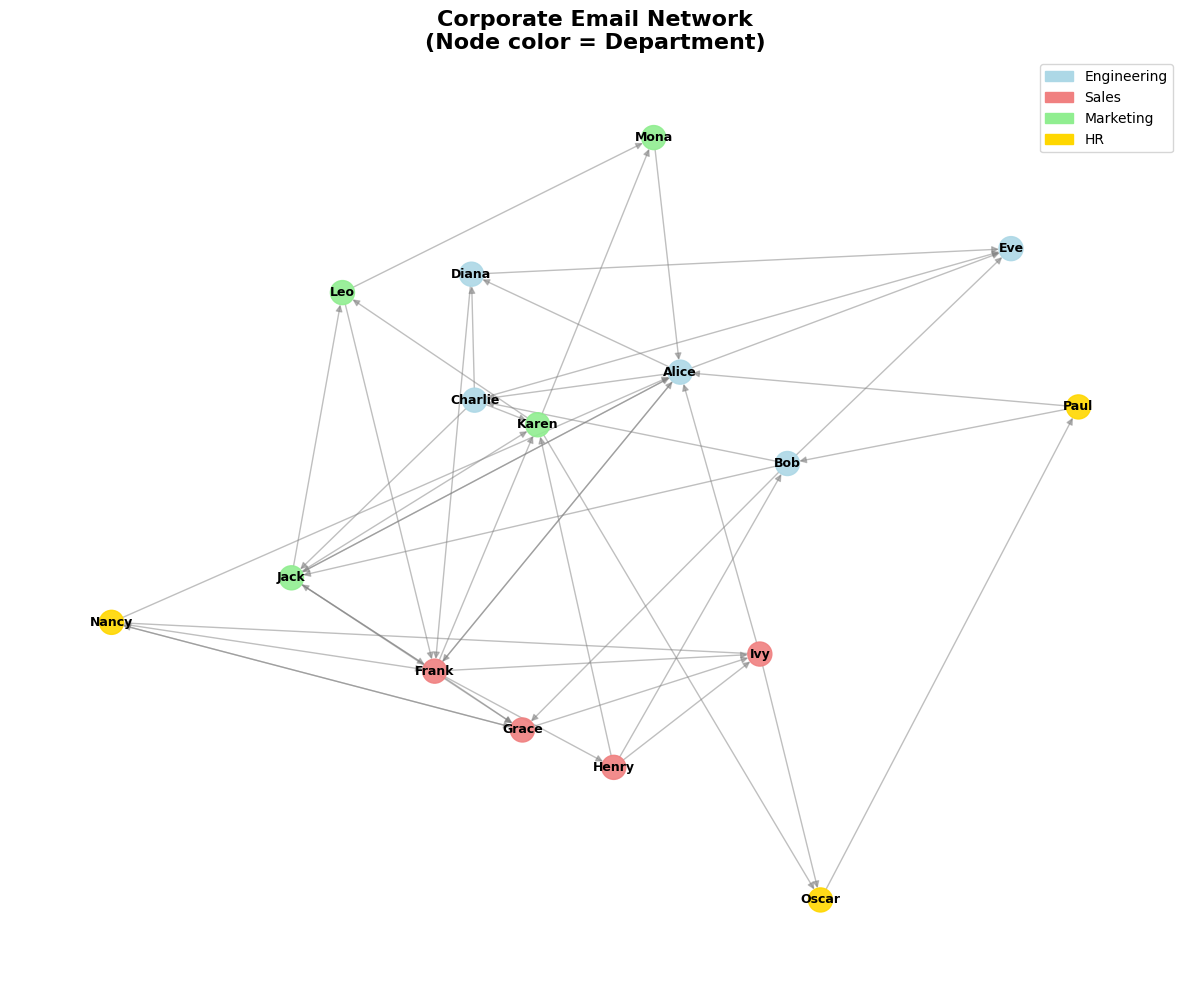


🏢 Department-level Analysis:

Engineering Department:
  Size: 5 employees
  Internal emails: 8
  Internal density: 40.00%

Sales Department:
  Size: 4 employees
  Internal emails: 5
  Internal density: 41.67%

Marketing Department:
  Size: 4 employees
  Internal emails: 5
  Internal density: 41.67%

HR Department:
  Size: 3 employees
  Internal emails: 1
  Internal density: 16.67%


In [16]:
# CELL 15: Complete example - Corporate email network
print("📧 Analyzing a corporate email network...")

# Create a simulated corporate email network
np.random.seed(42)
G = nx.DiGraph()  # Directed because emails can be one-way

# Departments
departments = {
    "Engineering": ["Alice", "Bob", "Charlie", "Diana", "Eve"],
    "Sales": ["Frank", "Grace", "Henry", "Ivy"],
    "Marketing": ["Jack", "Karen", "Leo", "Mona"],
    "HR": ["Nancy", "Oscar", "Paul"]
}

# Add all employees
all_employees = []
for dept, employees in departments.items():
    for emp in employees:
        G.add_node(emp, department=dept, emails_sent=np.random.randint(10, 100))
    all_employees.extend(employees)

# Add email connections (edges)
# People email within their department more often
for dept, employees in departments.items():
    for i, sender in enumerate(employees):
        # Email to department colleagues
        for receiver in employees[i+1:]:  # Avoid self-loops
            if np.random.random() < 0.7:  # 70% chance
                weight = np.random.randint(1, 10)
                G.add_edge(sender, receiver, weight=weight, type="intra-department")
        
        # Email to other departments
        other_depts = [d for d in departments if d != dept]
        for other_dept in other_depts:
            for receiver in departments[other_dept][:2]:  # Email first 2 people
                if np.random.random() < 0.3:  # 30% chance
                    weight = np.random.randint(1, 5)
                    G.add_edge(sender, receiver, weight=weight, type="inter-department")

print(f"Network has {G.number_of_nodes()} employees and {G.number_of_edges()} email connections")

# Analyze the network
print("\n📊 Network Analysis:")
print(f"1. Density: {nx.density(G):.3f} ({nx.density(G)*100:.1f}% of possible connections exist)")
print(f"2. Is strongly connected? {nx.is_strongly_connected(G)}")
print(f"3. Number of weakly connected components: {nx.number_weakly_connected_components(G)}")

# Who are the key people?
print("\n👥 Key Employees (by centrality):")

# Out-degree: who sends the most emails
out_degree = dict(G.out_degree())
print("\nMost active email senders:")
for emp, degree in sorted(out_degree.items(), key=lambda x: x[1], reverse=True)[:5]:
    dept = G.nodes[emp]['department']
    print(f"  {emp} ({dept}): {degree} recipients")

# In-degree: who receives the most emails
in_degree = dict(G.in_degree())
print("\nMost popular email recipients:")
for emp, degree in sorted(in_degree.items(), key=lambda x: x[1], reverse=True)[:5]:
    dept = G.nodes[emp]['department']
    print(f"  {emp} ({dept}): {degree} senders")

# Betweenness: who are the bridges
betweenness = nx.betweenness_centrality(G)
print("\nKey bridges between departments:")
for emp, centrality in sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:5]:
    dept = G.nodes[emp]['department']
    print(f"  {emp} ({dept}): {centrality:.3f}")

# Visualize
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, seed=42, k=1.5)

# Color nodes by department
dept_colors = {"Engineering": "lightblue", "Sales": "lightcoral", 
               "Marketing": "lightgreen", "HR": "gold"}
node_colors = [dept_colors[G.nodes[n]['department']] for n in G.nodes()]

# Draw
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=300, alpha=0.9)
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1, alpha=0.5, arrowsize=10)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

# Create legend
from matplotlib.patches import Patch
legend_patches = [Patch(color=color, label=dept) for dept, color in dept_colors.items()]
plt.legend(handles=legend_patches, loc='upper right')

plt.title("Corporate Email Network\n(Node color = Department)", fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

# Department-level analysis
print("\n🏢 Department-level Analysis:")
for dept, employees in departments.items():
    subgraph_nodes = [n for n in G.nodes() if G.nodes[n]['department'] == dept]
    subgraph = G.subgraph(subgraph_nodes)
    
    print(f"\n{dept} Department:")
    print(f"  Size: {len(employees)} employees")
    print(f"  Internal emails: {subgraph.number_of_edges()}")
    if len(employees) > 1:
        possible_internal = len(employees) * (len(employees) - 1)
        actual = subgraph.number_of_edges()
        print(f"  Internal density: {actual/possible_internal:.2%}")